# 08 — Chronos-2 con contexto extendido (512 → 8192 h)

**RESPIR-AI · TFG** — Extensión del barrido de contexto de Chronos-2 hasta el máximo que admite el
modelo, sobre las mismas 36 ventanas rolling-origin del protocolo v2 (H ∈ {6,12,24,48}, semilla 42).

**Máximo confirmado (paso 0)**: el snapshot descargado de `amazon/chronos-2` declara
`chronos_config.context_length = 8192`; `pipeline.model_context_length` devuelve ese mismo campo
(el `default_context_length` del pipeline es 2048). Rejilla: C ∈ {512, 1024, 2048, 4096, 8192} ×
covariables {U, F, PF}. P se omite: el barrido del cuaderno 07 mostró aporte marginal y cada
configuración extendida es costosa (C=8192 ≈ 12.7 s/ventana).

**Contexto con NaN-relleno**: los segmentos contiguos del test (1300/1179/630 h) no permiten
contextos contiguos > ~1252 h. Para toda esta rejilla —incluida C=512, por comparabilidad— el
contexto se construye sobre el índice horario completo hasta t0, con NaN en las horas sin medición
válida (Chronos-2 los tolera de forma nativa). Solo se usan valores ≤ t0 (sin fuga).

## 1. Preparación y verificación del máximo

In [ ]:
import os, json, glob, time, warnings
import numpy as np, pandas as pd, torch
from chronos import Chronos2Pipeline
from common_eval import *
warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42)

df, proto = load_all()
origins = get_origins(df, proto)
Y = true_targets(df, origins)

pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
print("model_context_length:", pipe.model_context_length)      # -> 8192
print("default_context_length:", pipe.default_context_length)  # -> 2048
print("chronos_config:", {k: v for k, v in pipe.model.config.to_dict()["chronos_config"].items()
                          if "length" in k or "patch" in k})
MAX_C = pipe.model_context_length

## 2. Constructor de contexto NaN-relleno (anti-fuga)

El target se enmascara fuera de segmentos útiles (`segment_id < 0` → NaN); las covariables de proceso igual; la meteo está completa en todo el índice. Si el dataset no alcanza C horas antes de t0, se rellena por la izquierda con NaN.

In [ ]:
y_nanfilled = df["our"].where(df.segment_id >= 0)

def build_ctx_nan(C, cov):
    dicts, nan_pcts = [], []
    for o in origins:
        i = o['iloc']
        lo = max(0, i - C + 1)
        tgt = y_nanfilled.iloc[lo:i+1].to_numpy(dtype=np.float32)
        if len(tgt) < C:
            tgt = np.concatenate([np.full(C-len(tgt), np.nan, dtype=np.float32), tgt])
        nan_pcts.append(100*np.isnan(tgt).mean())
        d = {"target": tgt}
        past = {}
        if cov in ("P","PF"):
            for c in PROC:
                v = df[c].where(df.segment_id>=0).iloc[lo:i+1].to_numpy(dtype=np.float32)
                if len(v) < C: v = np.concatenate([np.full(C-len(v), np.nan, dtype=np.float32), v])
                past[c] = v
        if cov in ("F","PF"):
            for c in METEO:
                v = df[c].iloc[lo:i+1].to_numpy(dtype=np.float32)
                if len(v) < C: v = np.concatenate([np.full(C-len(v), np.nan, dtype=np.float32), v])
                past[c] = v
            d["future_covariates"] = {c: df[c].iloc[i+1:i+49].to_numpy(dtype=np.float32) for c in METEO}
        if past: d["past_covariates"] = past
        dicts.append(d)
    return dicts, float(np.mean(nan_pcts))

## 3. Rejilla extendida C × {U, F, PF}

Si una C agotara la VRAM se reintenta con `batch_size=1`; en la práctica ninguna lo necesitó (pico 7.7 GB en C=8192).

In [ ]:
ext_rows, ext_win = [], []
def run_ext(C, cov):
    dicts, nan_pct = build_ctx_nan(C, cov)
    torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    t0 = time.perf_counter()
    try:
        qs, means = pipe.predict_quantiles(dicts, prediction_length=48)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        qs, means = pipe.predict_quantiles(dicts, prediction_length=48, batch_size=1)
    torch.cuda.synchronize()
    t_inf = (time.perf_counter()-t0)/36
    mem = torch.cuda.max_memory_allocated()/1e6
    P = np.stack([m.squeeze().numpy() for m in means]).astype(float)
    rows, wins = evaluate_preds(P, Y, "chronos2", f"zs_nanfill_C{C}_{cov}", t_inf, C, origins,
                                extra={"covariables": cov, "n_ventanas": 36,
                                       "pct_nan_contexto": round(nan_pct,2),
                                       "mem_gpu_pico_MB": round(mem,1)})
    for r in rows: r["C"] = C
    for w in wins: w["C"] = C; w["covariables"] = cov; w["relleno"] = "nan"
    return rows, wins

for C in [512, 1024, 2048, 4096, 8192]:
    for cov in ["U", "F", "PF"]:
        rows, wins = run_ext(C, cov)
        ext_rows += rows; ext_win += wins

pd.DataFrame(ext_rows).to_csv("results/barrido_contexto_extendido.csv", index=False)

## 4. Resultados (MAE@48, 36 ventanas — ejecución real)

| C | U | F | PF |
|---|---|---|---|
| 512 | 4.535 | 4.095 | 4.198 |
| 1024 | 4.406 | 4.148 | 4.179 |
| 2048 | 4.337 | 4.117 | 4.054 |
| 4096 | 4.296 | 4.144 | 4.133 |
| 8192 | 4.292 | 4.155 | 4.143 |

**Puente C=512**: el MAE univariante coincide exactamente con la C=512 contigua del cuaderno 07
(4.5345): en los 36 orígenes las últimas 512 h caen íntegras dentro del segmento, así que ambos
constructores generan el mismo contexto y las dos series son empalmables.

**Lectura**: la univariante mejora monótonamente con C (4.535 → 4.292, −5.4 %) — el contexto
largo actúa como sustituto parcial de la señal exógena — pero ni con 8192 h alcanza a las
variantes con futuras. F es plana o levemente decreciente en calidad al crecer C; PF tiene su
mínimo en C=2048 (4.054) sin batir al óptimo global del cuaderno 07 (C=256 contiguo + F, 4.018).

### Coste y % NaN por C (variante PF, la más costosa)

| C | t/ventana | VRAM pico (MB) | % NaN medio |
|---|---|---|---|
| 512 | 26 ms | 1000 | 0.0 |
| 1024 | 50 ms | 1445 | 6.3 |
| 2048 | 95 ms | 2343 | 9.3 |
| 4096 | 2655 ms | 4140 | 17.9 |
| 8192 | 12727 ms | 7732 | 21.2 |

C=8192 cabe en la RTX 3070 al límite (7.7/8 GB) con un coste ~495× el de C=512 en la variante PF
(la univariante es mucho más barata: 7 ms → 141 ms, ~20×, porque procesa una sola serie por ventana).

## 5. Conclusión

No merece la pena ir más allá de C≈256–512 en esta planta: ningún punto de la rejilla extendida mejora al óptimo contiguo C=256+F (4.018). El contexto largo solo es defendible sin acceso a pronóstico meteorológico (C=4096 univariante recorta el 60 % de la distancia hacia las variantes con futuras, a ~2.7 s/predicción). Ver `resumen_contexto_extendido.md` y `figures/fig_mae_vs_contexto_extendido.png`.

## Resultados guardados

Este cuaderno requiere horas de GPU para re-ejecutarse por completo; la celda siguiente carga los resultados ya calculados desde `results/` y puede ejecutarse en cualquier máquina.

covariables      F     PF      U
C                               
512          4.095  4.198  4.535
1024         4.148  4.179  4.406
2048         4.117  4.054  4.337
4096         4.144  4.133  4.296
8192         4.155  4.143  4.292


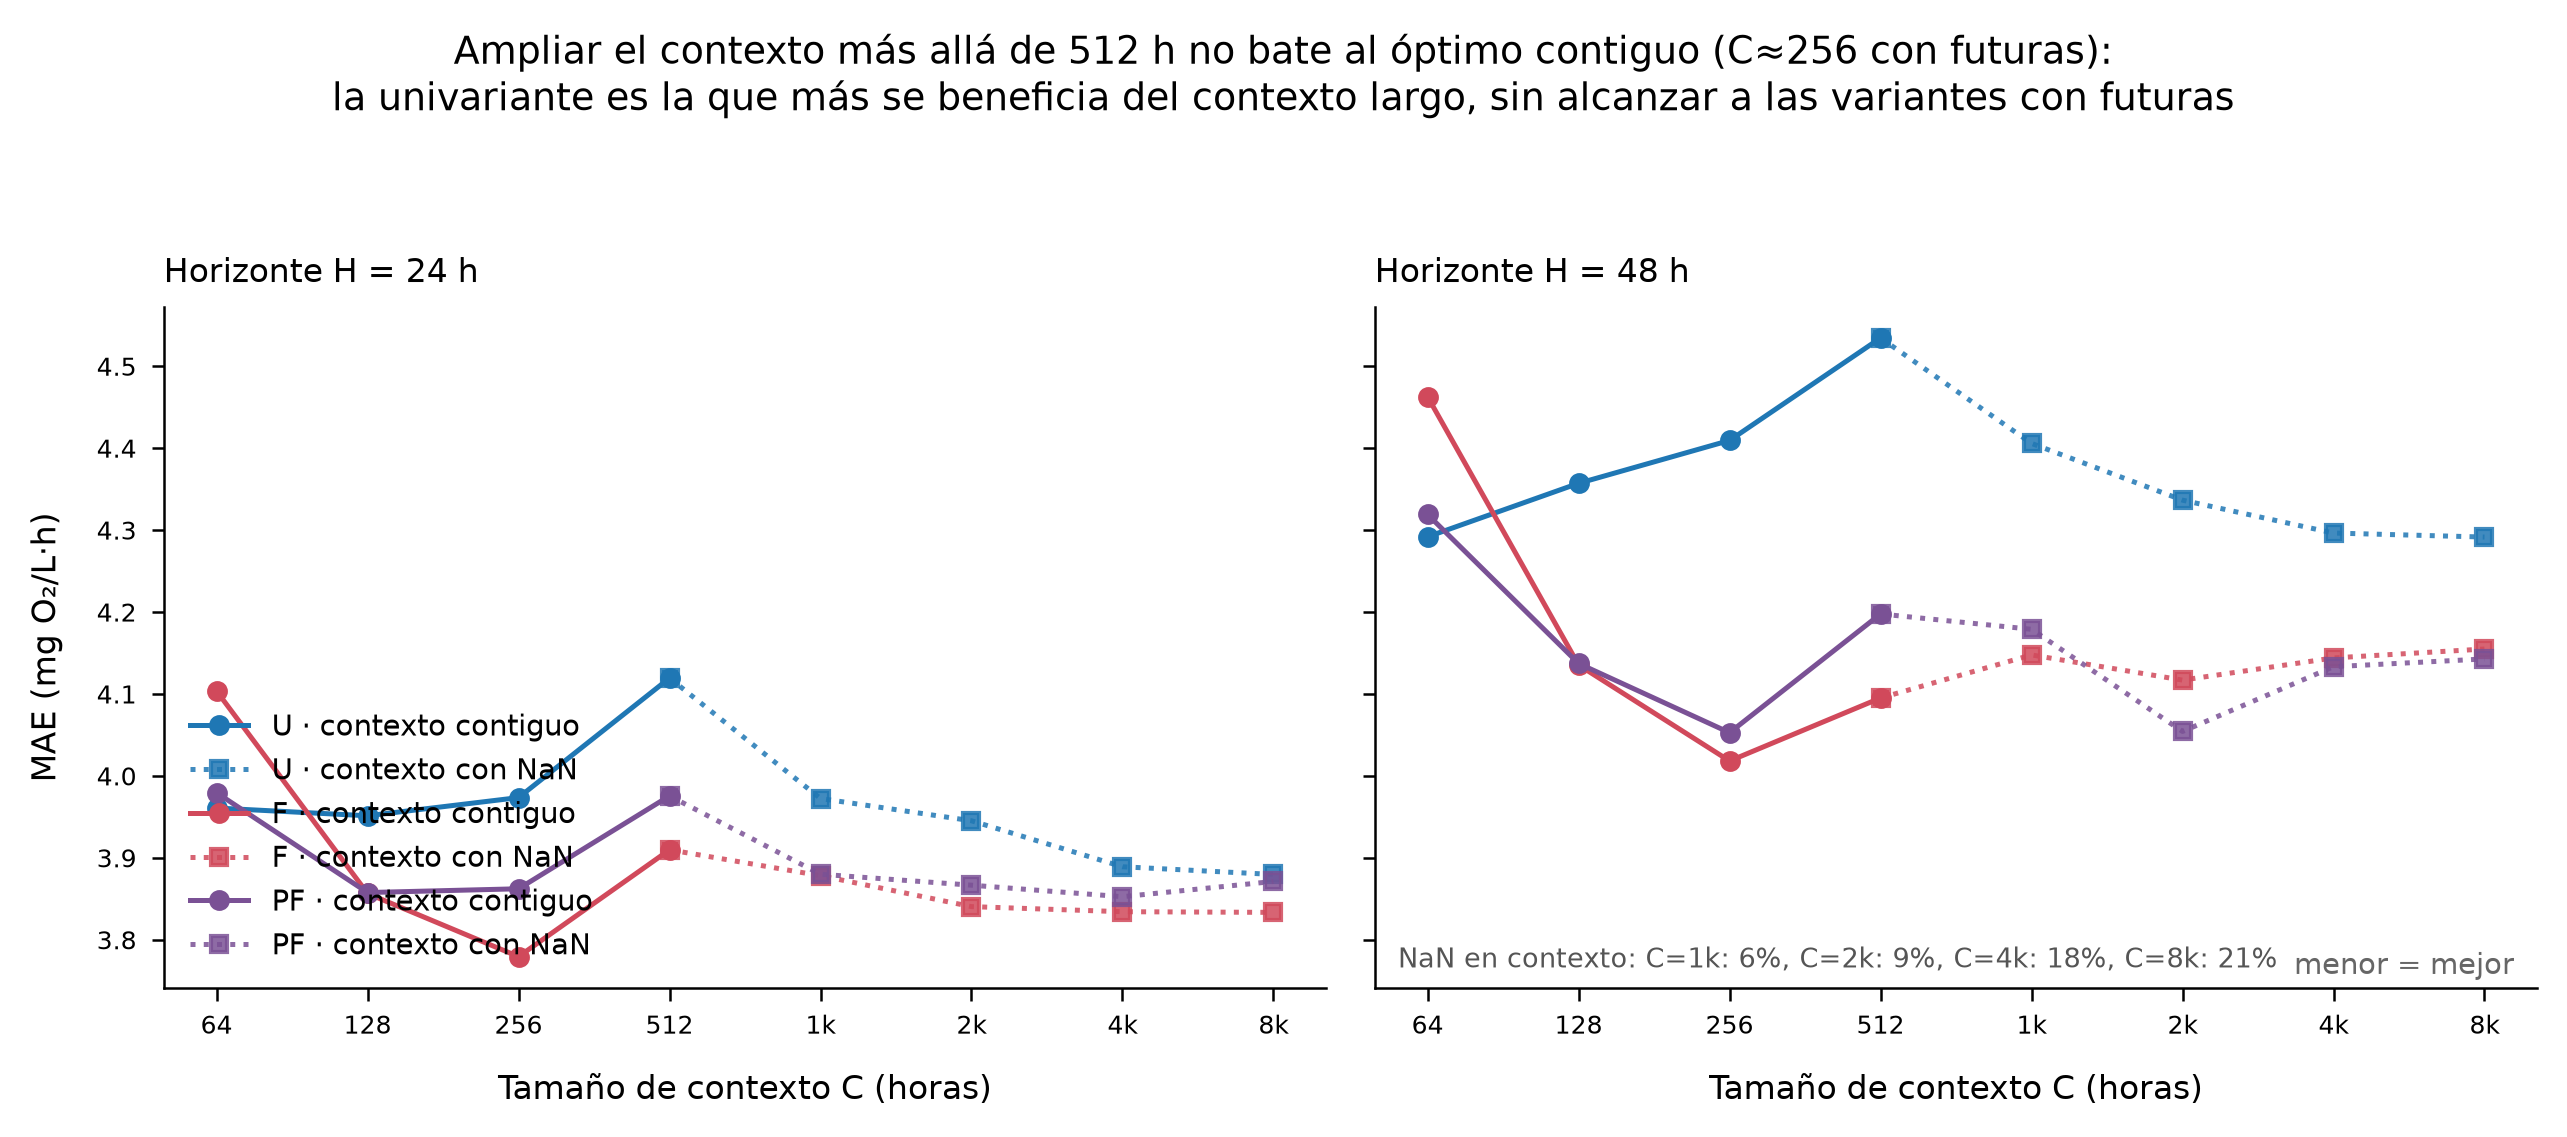

In [1]:
# Resultados guardados (esta celda se puede ejecutar sin GPU)
import os, sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"common_eval.py").exists() else Path.cwd().parent
os.chdir(ROOT)
import pandas as pd
from IPython.display import Image, display
d = pd.read_csv("results/barrido_contexto_extendido.csv")
print(d[d.H==48].pivot(index="C", columns="covariables", values="MAE").round(3).to_string())
display(Image("figures/fig_mae_vs_contexto_extendido.png", width=900))